In [1]:
import numpy as np

def generate_uniform_grid(n_eta=20, n_rho=20, n_v0=25):
    eta_vals = np.linspace(0, 1, n_eta)
    rho_vals = np.linspace(0.1, 3, n_rho)
    v0_vals = np.linspace(0.01, 0.5, n_v0)

    ETA, RHO, V0 = np.meshgrid(eta_vals, rho_vals, v0_vals, indexing="ij")
    data = np.column_stack([ETA.ravel(), RHO.ravel(), V0.ravel()])

    return data

finalSamples = generate_uniform_grid(n_eta=75, n_rho=75, n_v0=75)

print(finalSamples.shape)

np.savetxt("/Users/brandonle/Documents/Viscek/testPoints.txt", finalSamples, fmt="%.8f", delimiter=" ")

(421875, 3)


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def print_label_percentages(labels, name="Dataset"):
    labels = np.asarray(labels).astype(int)
    total = len(labels)

    print()
    print(f"{name} label distribution:")
    print(f"Total points: {total}")

    for phase in sorted(np.unique(labels)):
        count = np.sum(labels == phase)
        percent = 100 * count / total
        print(f"  Label {phase}: {count} points, {percent:.2f}%")


def compute_accuracy(model, data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

eta, rho, v0, label = np.loadtxt("/Users/brandonle/Documents/Viscek/labeledDataset.csv", delimiter=",", unpack=True)

X = np.column_stack((eta, rho, v0)).astype(np.float32)
y = label.astype(np.int64)

print_label_percentages(y, name="Original labeled dataset")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18, stratify=y)

print_label_percentages(y_train, name="Training set")
print_label_percentages(y_test, name="Test set")

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 3))

    def forward(self, x):
        return self.net(x)

model = Classifier()

class_counts = np.bincount(y_train.numpy())
class_weights = len(y_train) / (len(class_counts) * class_counts)

class_weights = torch.tensor(class_weights, dtype=torch.float32)

print()
print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  Label {i}: {w.item():.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200
print_every = 25

print()
print("Training model:")

for epoch in range(epochs):
    model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == epochs - 1:
        train_acc = compute_accuracy(model, train_loader)
        test_acc = compute_accuracy(model, test_loader)

        print(
            f"Epoch {epoch + 1:3d}/{epochs}, "
            f"Loss: {avg_loss:.4f}, "
            f"Train Acc: {100 * train_acc:.2f}%, "
            f"Test Acc: {100 * test_acc:.2f}%"
        )

train_acc = compute_accuracy(model, train_loader)
test_acc = compute_accuracy(model, test_loader)

print()
print("Final performance:")
print(f"  Training accuracy: {100 * train_acc:.2f}%")
print(f"  Test accuracy:     {100 * test_acc:.2f}%")


neweta, newrho, newv0 = np.loadtxt("/Users/brandonle/Documents/Viscek/testPoints.txt", delimiter=" ", unpack=True)

new_data = np.column_stack((neweta, newrho, newv0)).astype(np.float32)
new_data_tensor = torch.tensor(new_data, dtype=torch.float32)

model.eval()

with torch.no_grad():
    new_outputs = model(new_data_tensor)
    new_probs = torch.softmax(new_outputs, dim=1)

    newLabel = torch.argmax(new_probs, dim=1).numpy()
    confidence = torch.max(new_probs, dim=1).values.numpy()


print_label_percentages(newLabel, name="Predicted evenly spaced grid")

print()
print("Prediction confidence on new grid:")
print(f"  Mean confidence: {100 * np.mean(confidence):.2f}%")
print(f"  Min confidence:  {100 * np.min(confidence):.2f}%")
print(f"  Max confidence:  {100 * np.max(confidence):.2f}%")

for cutoff in [0.5, 0.7, 0.9]:
    percent_above = 100 * np.mean(confidence >= cutoff)
    print(f"  Points with confidence >= {cutoff:.1f}: {percent_above:.2f}%")


new_df = pd.DataFrame({
    "eta": neweta,
    "rho": newrho,
    "v0": newv0,
    "label": newLabel
})

new_df.to_csv("/Users/brandonle/Documents/Viscek/fixedLabeledDataset.csv", index=False, header=False)

/Users/brandonle/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Original labeled dataset label distribution:
Total points: 193
  Label 0: 142 points, 73.58%
  Label 1: 38 points, 19.69%
  Label 2: 13 points, 6.74%

Training set label distribution:
Total points: 154
  Label 0: 113 points, 73.38%
  Label 1: 30 points, 19.48%
  Label 2: 11 points, 7.14%

Test set label distribution:
Total points: 39
  Label 0: 29 points, 74.36%
  Label 1: 8 points, 20.51%
  Label 2: 2 points, 5.13%

Class weights:
  Label 0: 0.4543
  Label 1: 1.7111
  Label 2: 4.6667

Training model:
Epoch   1/200, Loss: 1.1305, Train Acc: 48.70%, Test Acc: 58.97%
Epoch  25/200, Loss: 0.7812, Train Acc: 86.36%, Test Acc: 82.05%
Epoch  50/200, Loss: 0.5898, Train Acc: 88.31%, Test Acc: 84.62%
Epoch  75/200, Loss: 0.5116, Train Acc: 90.91%, Test Acc: 84.62%
Epoch 100/200, Loss: 0.4776, Train Acc: 91.56%, Test Acc: 87.18%
Epoch 125/200, Loss: 0.4028, Train Acc: 92.21%, Test Acc: 92.31%
Epoch 150/200, Loss: 0.3453, Train Acc: 92.21%, Test Acc: 89.74%
Epoch 175/200, Loss: 0.3336, Train Ac

In [ ]:
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

eta, rho, v0, label = np.loadtxt('/Users/brandonle/Documents/Viscek/fixedLabeledDataset.csv', delimiter=',', unpack=True)

label = label.astype(int)

customMap = ListedColormap(['skyblue', 'khaki', 'palegreen'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], customMap.N)

fig = plt.figure(figsize=(7, 6.5))
ax = fig.add_subplot(projection='3d')

ax.scatter(eta, rho, v0, c=label, cmap=customMap, norm=norm, s=1)

ax.set_xlabel(r"Noise $\eta$", fontsize=16, labelpad=10)
ax.set_ylabel(r"Density $\rho$", fontsize=16, labelpad=10)
ax.set_zlabel(r"Speed $v_0$", fontsize=16, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='z', which='major', labelsize=12)

ax.view_init(elev=25, azim=-60)
ax.set_box_aspect(None, zoom=0.85)

fig.tight_layout(pad=0.5)

plt.show()

: 

v0 = 0.01662: original points near slice = 19
v0 = 0.04311: original points near slice = 8
v0 = 0.10932: original points near slice = 4


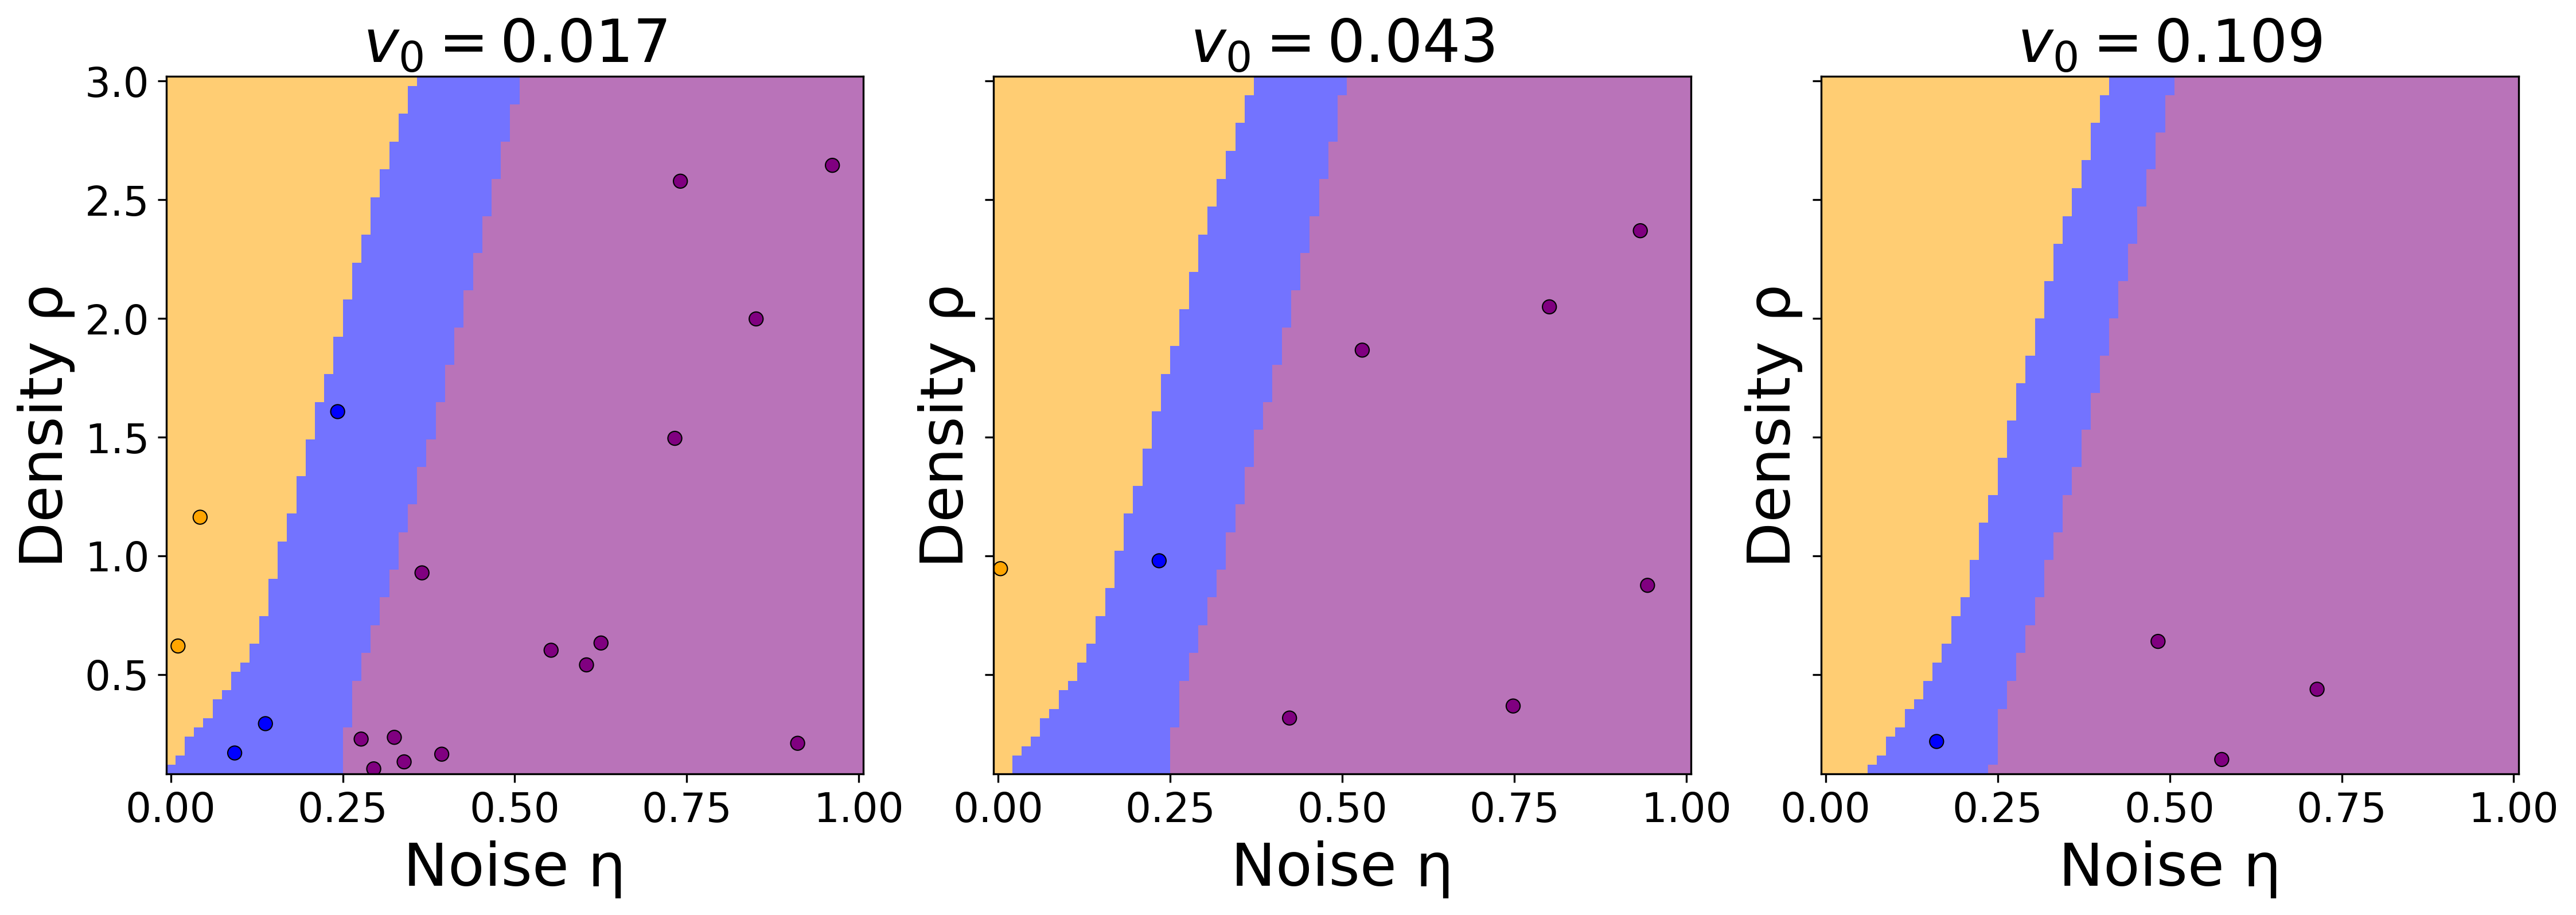

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

eta_orig, rho_orig, v0_orig, label_orig = np.loadtxt("/Users/brandonle/Documents/Viscek/labeledDataset.csv", delimiter=",", unpack=True)
label_orig = label_orig.astype(int)

eta_grid, rho_grid, v0_grid, label_grid = np.loadtxt("/Users/brandonle/Documents/Viscek/fixedLabeledDataset.csv", delimiter=",", unpack=True)
label_grid = label_grid.astype(int)

customMap = ListedColormap(["purple", "orange", "blue"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], customMap.N)

def nearest_value(arr, target):
    arr = np.asarray(arr)
    return arr[np.argmin(np.abs(arr - target))]

def centers_to_edges(x):
    x = np.asarray(np.sort(np.unique(x)))

    if len(x) == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])

    dx = np.diff(x)
    edges = np.zeros(len(x) + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges

eta_vals = np.sort(np.unique(eta_grid))
rho_vals = np.sort(np.unique(rho_grid))
v0_vals = np.sort(np.unique(v0_grid))

eta_edges = centers_to_edges(eta_vals)
rho_edges = centers_to_edges(rho_vals)

eta_index = {val: i for i, val in enumerate(eta_vals)}
rho_index = {val: i for i, val in enumerate(rho_vals)}

if len(v0_vals) > 1:
    v0_spacing = np.min(np.diff(v0_vals))
    overlay_tol = 0.5 * v0_spacing
else:
    overlay_tol = 1e-8

requested_slices = np.array([0.01662, 0.04311, 0.10932])

slice_values = np.array([nearest_value(v0_vals, val) for val in requested_slices])

for val in slice_values:
    count_near = np.sum(np.abs(v0_orig - val) <= overlay_tol)
    print(f"v0 = {val:.5f}: original points near slice = {count_near}")

n_panels = len(slice_values)
ncols = 3
nrows = 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, actual_v0 in zip(axes, slice_values):
    grid_mask = np.isclose(v0_grid, actual_v0)

    eta_slice = eta_grid[grid_mask]
    rho_slice = rho_grid[grid_mask]
    label_slice = label_grid[grid_mask]

    Z = np.full((len(rho_vals), len(eta_vals)), np.nan)

    for e, r, lab in zip(eta_slice, rho_slice, label_slice):
        i = eta_index[e]
        j = rho_index[r]
        Z[j, i] = lab

    ax.pcolormesh(eta_edges, rho_edges, Z, cmap=customMap, norm=norm, shading="auto", alpha=0.55)

    orig_mask = np.abs(v0_orig - actual_v0) <= overlay_tol

    ax.scatter(eta_orig[orig_mask], rho_orig[orig_mask], c=label_orig[orig_mask], cmap=customMap, 
               norm=norm, s=34, marker="o", edgecolors="black", linewidths=0.5)

    ax.set_title(f"$v_0={actual_v0:.3f}$", fontsize=25)
    ax.set_xlabel("Noise η", fontsize=25)
    ax.set_ylabel("Density ρ", fontsize=25)
    ax.tick_params(axis="both", labelsize=17)
    ax.set_box_aspect(1)

for ax in axes[n_panels:]:
    ax.axis("off")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Disorder', markerfacecolor='purple', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Order', markerfacecolor='orange', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Coexistence', markerfacecolor='blue', markeredgecolor='black', markersize=8),
]

plt.tight_layout()
plt.show()